Saving 0000.csv to 0000.csv
Loaded: 0000.csv
Using features: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES']
Data shape: (32399, 11)
Windows shape: (32300, 100, 11)
Flattened windows shape: (32300, 1100)


/tmp/ipython-input-572720614.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate().fillna(method='bfill').fillna(method='ffill')


Train windows: (27455, 1100) Val windows: (4845, 1100)
LOF trained (novelty=True).
Anomalous windows (count): 11518 / 32300
Percent of samples flagged anomalous: 55.8474%


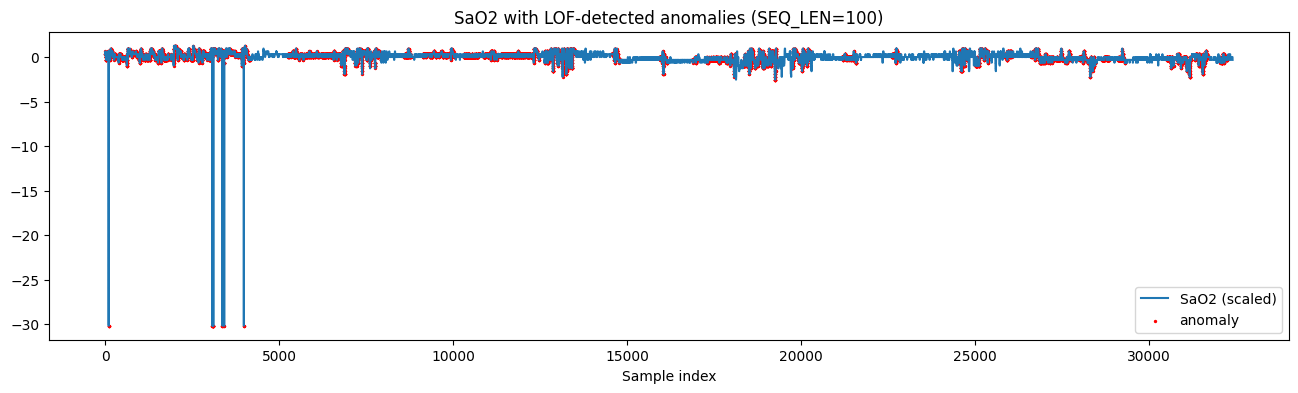

Top anomalous windows (by anomaly score):
1. window_idx=33, start_sample=33, score=4.265960, model_pred=-1
2. window_idx=3012, start_sample=3012, score=4.265496, model_pred=-1
3. window_idx=34, start_sample=34, score=4.257182, model_pred=-1
4. window_idx=30, start_sample=30, score=4.248411, model_pred=-1
5. window_idx=3013, start_sample=3013, score=4.200382, model_pred=-1
6. window_idx=8, start_sample=8, score=4.181907, model_pred=-1
7. window_idx=46, start_sample=46, score=4.153765, model_pred=-1
8. window_idx=3014, start_sample=3014, score=4.135264, model_pred=-1
9. window_idx=20, start_sample=20, score=4.128129, model_pred=-1
10. window_idx=0, start_sample=0, score=4.120326, model_pred=-1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'\nfrom sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score\n\nlabels = pd.read_csv("labels.csv")[\'label\'].values  # example\ny_true = labels.astype(int)\ny_pred = sample_anomaly.astype(int)\n\nprint("Precision:", precision_score(y_true, y_pred))\nprint("Recall:", recall_score(y_true, y_pred))\nprint("F1:", f1_score(y_true, y_pred))\n\n# For ROC AUC use continuous per-sample score (map window scores to samples, e.g., per-sample max)\nper_sample_score = np.zeros(n_samples)\nfor i in range(len(anomaly_score)):\n    s = window_starts[i]\n    per_sample_score[s:s+SEQ_LEN] = np.maximum(per_sample_score[s:s+SEQ_LEN], anomaly_score[i])\nprint("ROC AUC:", roc_auc_score(y_true, per_sample_score))\n'

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
from google.colab import files

uploaded = files.upload()  
csv_filename = list(uploaded.keys())[0]
print("Loaded:", csv_filename)


df = pd.read_csv(csv_filename)
if 'sample_index' in df.columns:
    df = df.drop(columns=['sample_index'])
df = df.select_dtypes(include=[np.number]).copy()
print("Using features:", df.columns.tolist())
n_samples, n_features = df.shape
print("Data shape:", df.shape)


df = df.interpolate().fillna(method='bfill').fillna(method='ffill')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)   

def create_windows(X, seq_len=100, step=1):
    n_samples, n_features = X.shape
    windows = []
    starts = []
    for start in range(0, n_samples - seq_len + 1, step):
        windows.append(X[start:start+seq_len])
        starts.append(start)
    return np.stack(windows), np.array(starts)

SEQ_LEN = 100   
STEP = 1
X_windows, window_starts = create_windows(X_scaled, seq_len=SEQ_LEN, step=STEP)
print("Windows shape:", X_windows.shape) 

X_flat = X_windows.reshape((X_windows.shape[0], -1))
print("Flattened windows shape:", X_flat.shape)

train_X, val_X, train_idx, val_idx = train_test_split(
    X_flat, np.arange(X_flat.shape[0]), test_size=0.15, random_state=42
)
print("Train windows:", train_X.shape, "Val windows:", val_X.shape)


lof = LocalOutlierFactor(
    n_neighbors=20,
    algorithm='auto',
    leaf_size=30,
    metric='minkowski',
    p=2,
    novelty=True 
)
lof.fit(train_X)
print("LOF trained (novelty=True).")

pred_windows = lof.predict(X_flat)           
decision_scores = lof.decision_function(X_flat)  
anomaly_score = -decision_scores            

anomaly_mask_windows = pred_windows == -1
print("Anomalous windows (count):", anomaly_mask_windows.sum(), "/", len(anomaly_mask_windows))

percentile = 98
threshold_pct = np.percentile(anomaly_score, percentile)
anomaly_mask_windows_pct = anomaly_score >= threshold_pct

n_windows = X_flat.shape[0]
sample_anomaly = np.zeros(n_samples, dtype=bool)

for win_idx, is_anom in enumerate(anomaly_mask_windows):
    if is_anom:
        start = window_starts[win_idx]
        sample_anomaly[start:start+SEQ_LEN] = True

pct_samples_anomalous = sample_anomaly.sum() / n_samples * 100
print(f"Percent of samples flagged anomalous: {pct_samples_anomalous:.4f}%")

feature_idx = 0
feature_name = df.columns[feature_idx]
time = np.arange(n_samples)

plt.figure(figsize=(16,4))
plt.plot(time, X_scaled[:, feature_idx], label=f"{feature_name} (scaled)")
anom_idxs = np.where(sample_anomaly)[0]
plt.scatter(anom_idxs, X_scaled[anom_idxs, feature_idx], color='red', s=2, label='anomaly')
plt.xlabel("Sample index")
plt.legend()
plt.title(f"{feature_name} with LOF-detected anomalies (SEQ_LEN={SEQ_LEN})")
plt.show()

top_k = 10
top_idx = np.argsort(anomaly_score)[-top_k:][::-1]
print("Top anomalous windows (by anomaly score):")
for r, idx in enumerate(top_idx, 1):
    start = window_starts[idx]
    print(f"{r}. window_idx={idx}, start_sample={start}, score={anomaly_score[idx]:.6f}, model_pred={pred_windows[idx]}")


out_df = pd.DataFrame({
    'sample_index': np.arange(n_samples),
    **{col: df[col].values for col in df.columns},
    'is_anomaly_sample': sample_anomaly.astype(int)
})
out_df.to_csv("lof_anomaly_by_sample.csv", index=False)
pd.DataFrame({'window_start': window_starts, 'anomaly_window': anomaly_mask_windows.astype(int),
              'anomaly_score': anomaly_score}).to_csv("lof_window_results.csv", index=False)

files.download("lof_anomaly_by_sample.csv")
files.download("lof_window_results.csv")

joblib.dump(lof, "lof_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved lof_model.pkl and scaler.pkl")
files.download("lof_model.pkl")
files.download("scaler.pkl")